<a href="https://colab.research.google.com/github/reyalejandro453-dot/DeepLearning/blob/main/week4/week4_tecnicasregularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9219 - loss: 0.2640 - val_accuracy: 0.9541 - val_loss: 0.1516
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9659 - loss: 0.1141 - val_accuracy: 0.9658 - val_loss: 0.1126
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9772 - loss: 0.0770 - val_accuracy: 0.9703 - val_loss: 0.1019
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9817 - loss: 0.0584 - val_accuracy: 0.9734 - val_loss: 0.0927
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0440 - val_accuracy: 0.9727 - val_loss: 0.0943
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9884 - loss: 0.0370 - val_accuracy: 0.9754 - val_loss: 0.0946
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9903 - loss: 0.0297 - val_accuracy: 0.9760 - val_loss: 0.0921
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9919 - loss: 0.0246 -

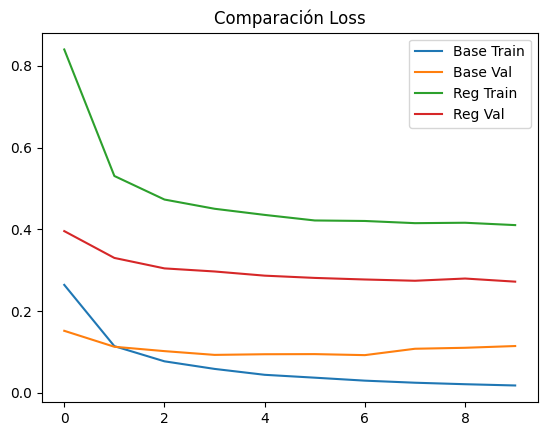

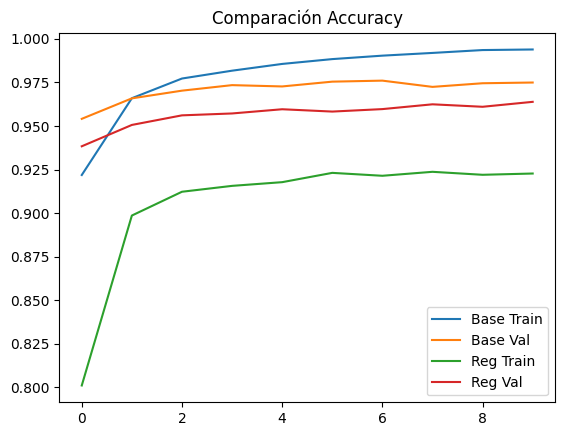

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9753 - loss: 0.0988
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9662 - loss: 0.2664
Modelo Base - Accuracy: 0.9753000140190125
Modelo Regularizado - Accuracy: 0.9661999940872192


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0
# Aplanar imágenes
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

#Modelo base
model_base = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

#Modelo con regularizacion
model_reg = keras.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_reg = model_reg.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# LOSS
plt.figure()
plt.plot(history_base.history['loss'], label='Base Train')
plt.plot(history_base.history['val_loss'], label='Base Val')
plt.plot(history_reg.history['loss'], label='Reg Train')
plt.plot(history_reg.history['val_loss'], label='Reg Val')
plt.legend()
plt.title("Comparación Loss")
plt.show()

# ACCURACY
plt.figure()
plt.plot(history_base.history['accuracy'], label='Base Train')
plt.plot(history_base.history['val_accuracy'], label='Base Val')
plt.plot(history_reg.history['accuracy'], label='Reg Train')
plt.plot(history_reg.history['val_accuracy'], label='Reg Val')
plt.legend()
plt.title("Comparación Accuracy")
plt.show()

loss_base, acc_base = model_base.evaluate(x_test, y_test)
loss_reg, acc_reg = model_reg.evaluate(x_test, y_test)

print("Modelo Base - Accuracy:", acc_base)
print("Modelo Regularizado - Accuracy:", acc_reg)

Overfitting:
El modelo base presenta overfitting, ya que el loss de entrenamiento disminuye continuamente mientras el loss de validación se estabiliza o aumenta.

Efecto de la regularización:
La aplicación de Dropout y regularización L2 reduce el overfitting, haciendo que las curvas de entrenamiento y validación sean más cercanas.

Hallazgos:
La regularización mejora la capacidad de generalización del modelo, aunque puede reducir ligeramente la precisión en entrenamiento.